In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/yashjaiswal04518/indicxnli-preprocessed-v1/manifest.json
/kaggle/input/datasets/yashjaiswal04518/indicxnli-preprocessed-v1/te/train_392702.parquet
/kaggle/input/datasets/yashjaiswal04518/indicxnli-preprocessed-v1/te/train_500.parquet
/kaggle/input/datasets/yashjaiswal04518/indicxnli-preprocessed-v1/te/train_1000.parquet
/kaggle/input/datasets/yashjaiswal04518/indicxnli-preprocessed-v1/te/test.parquet
/kaggle/input/datasets/yashjaiswal04518/indicxnli-preprocessed-v1/te/train_50.parquet
/kaggle/input/datasets/yashjaiswal04518/indicxnli-preprocessed-v1/te/valid.parquet
/kaggle/input/datasets/yashjaiswal04518/indicxnli-preprocessed-v1/te/train_100.parquet
/kaggle/input/datasets/yashjaiswal04518/indicxnli-preprocessed-v1/hi/train_392702.parquet
/kaggle/input/datasets/yashjaiswal04518/indicxnli-preprocessed-v1/hi/train_500.parquet
/kaggle/input/datasets/yashjaiswal04518/indicxnli-preprocessed-v1/hi/train_1000.parquet
/kaggle/input/datasets/yashjaiswal04518/indicxnli-pr

In [2]:
from transformers import AutoModelForSequenceClassification

MODEL_NAME = "xlm-roberta-base"
NUM_LABELS = 3

def load_base_model():
    return AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS
    ).cuda()

In [3]:
def report_trainable(model, name):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print("=" * 60)
    print(name)
    print(f"Trainable : {trainable:,}")
    print(f"Total     : {total:,}")
    print(f"Percentage: {100 * trainable / total:.4f}%")

In [4]:
base_model = load_base_model()
report_trainable(base_model, "Full Fine-Tuning")

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Full Fine-Tuning
Trainable : 278,045,955
Total     : 278,045,955
Percentage: 100.0000%


In [5]:
base_model = load_base_model()

for name, module in base_model.named_modules():
    if any(x in name for x in ["query", "key", "value", "dense"]):
        print(name)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


classifier.dense
roberta.encoder.layer.0.attention.self.query
roberta.encoder.layer.0.attention.self.key
roberta.encoder.layer.0.attention.self.value
roberta.encoder.layer.0.attention.output.dense
roberta.encoder.layer.0.intermediate.dense
roberta.encoder.layer.0.output.dense
roberta.encoder.layer.1.attention.self.query
roberta.encoder.layer.1.attention.self.key
roberta.encoder.layer.1.attention.self.value
roberta.encoder.layer.1.attention.output.dense
roberta.encoder.layer.1.intermediate.dense
roberta.encoder.layer.1.output.dense
roberta.encoder.layer.2.attention.self.query
roberta.encoder.layer.2.attention.self.key
roberta.encoder.layer.2.attention.self.value
roberta.encoder.layer.2.attention.output.dense
roberta.encoder.layer.2.intermediate.dense
roberta.encoder.layer.2.output.dense
roberta.encoder.layer.3.attention.self.query
roberta.encoder.layer.3.attention.self.key
roberta.encoder.layer.3.attention.self.value
roberta.encoder.layer.3.attention.output.dense
roberta.encoder.layer.3

In [6]:
target_modules=[
    "query",
    "value"
]

Reason:

Standard configuration in the literature.
Strong empirical support.
Lower parameter count than QKV.
Better comparability with prior work.
Avoids introducing an unnecessary experimental variable.

## Step 1 — LoRA

In [7]:
import peft
import transformers
import torch

print("PEFT:", peft.__version__)
print("Transformers:", transformers.__version__)
print("Torch:", torch.__version__)

try:
    import torchao
    print("TorchAO:", torchao.__version__)
except Exception as e:
    print(e)

PEFT: 0.19.1
Transformers: 5.0.0
Torch: 2.10.0+cu128
TorchAO: 0.10.0


In [8]:
!pip uninstall -y torchao

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


In [9]:
try:
    import torchao
    print("TorchAO:", torchao.__version__)
except ImportError:
    print("✓ TorchAO not installed")

TorchAO: 0.10.0


In [10]:
from peft import (
    LoraConfig,
    TaskType,
    get_peft_model
)

base_model = load_base_model()

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.SEQ_CLS,
    target_modules=["query", "value"]
)

lora_model = get_peft_model(base_model, lora_config)
report_trainable(lora_model, "LoRA")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


LoRA
Trainable : 887,811
Total     : 278,933,766
Percentage: 0.3183%


Your notebook should record this issue for reproducibility.

- Issue Encountered
  peft==0.19.1 incompatible with Kaggle's 
- Problem	
preinstalled torchao==0.10.0
- Resolution
Uninstalled torchao and restarted kernel

## Next Step — DoRA Verification

In [11]:
from peft import LoraConfig, TaskType, get_peft_model

base_model = load_base_model()

dora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    bias="none",
    use_dora=True,
    task_type=TaskType.SEQ_CLS,
    target_modules=["query", "value"]
)

dora_model = get_peft_model(base_model, dora_config)

report_trainable(dora_model, "DoRA")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DoRA
Trainable : 906,243
Total     : 278,952,198
Percentage: 0.3249%


## Next: IA³ Verification

In [12]:
from peft import IA3Config, TaskType, get_peft_model

base_model = load_base_model()

ia3_config = IA3Config(
    task_type=TaskType.SEQ_CLS,
    target_modules=["key", "value", "output.dense"],
    feedforward_modules=["output.dense"]
)

ia3_model = get_peft_model(base_model, ia3_config)

report_trainable(ia3_model, "IA3")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


IA3
Trainable : 657,411
Total     : 278,703,366
Percentage: 0.2359%


In [13]:
import pandas as pd

results = pd.DataFrame({
    "Method": [
        "Full Fine-Tuning",
        "LoRA",
        "DoRA",
        "IA3"
    ],
    "Trainable Parameters": [
        278_045_955,
        887_811,
        906_243,
        657_411
    ],
    "Total Parameters": [
        278_045_955,
        278_933_766,
        278_952_198,
        278_703_366
    ]
})

results["Trainable %"] = (
    results["Trainable Parameters"]
    / results["Total Parameters"]
    * 100
).round(4)

display(results)

,Method,Trainable Parameters,Total Parameters,Trainable %
0,Full Fine-Tuning,278045955,278045955,100.0000
1,LoRA,887811,278933766,0.3183
2,DoRA,906243,278952198,0.3249
3,IA3,657411,278703366,0.2359


# PEFT Environment Verification
## Objective
Verify that all planned parameter-efficient fine-tuning methods can be successfully attached to xlm-roberta-base before constructing the experimental training pipeline.

## Results
* Full Fine-Tuning exposes all model parameters for optimization (100% trainable).
* LoRA successfully injects low-rank adapters into the Query and Value projection layers, reducing trainable parameters to 0.3183%.
* DoRA successfully extends LoRA with weight decomposition, requiring 0.3249% trainable parameters.
* IA³ successfully injects multiplicative scaling vectors into attention and feed-forward layers, requiring only 0.2359% trainable parameters.

During verification, an incompatibility between peft==0.19.1 and Kaggle's pre-installed torchao==0.10.0 was encountered. Removing the incompatible torchao package and restarting the notebook resolved the issue. All PEFT methods were subsequently verified successfully.

## Step 1 — Benchmark Function

In [14]:
import time
import torch
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def benchmark_training_step(
    model,
    batch_size=16,
    max_length=128,
    device="cuda"
):
    model = model.to(device)
    model.train()

    batch = tokenizer(
        ["This is a test premise."] * batch_size,
        ["This is a test hypothesis."] * batch_size,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )

    batch = {k: v.to(device) for k, v in batch.items()}
    labels = torch.zeros(batch_size, dtype=torch.long).to(device)

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=2e-5
    )

    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    start = time.perf_counter()

    outputs = model(**batch, labels=labels)
    loss = outputs.loss

    loss.backward()

    optimizer.step()
    optimizer.zero_grad()

    end = time.perf_counter()

    peak_memory = torch.cuda.max_memory_allocated() / 1024**3

    print("=" * 60)
    print(f"Loss              : {loss.item():.4f}")
    print(f"Time / step       : {end-start:.3f} sec")
    print(f"Peak GPU Memory   : {peak_memory:.2f} GB")

    return {
        "loss": loss.item(),
        "time": end-start,
        "memory": peak_memory
    }

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## Step 2 — Benchmark Full Fine-Tuning

In [15]:
fft_model = load_base_model()

fft_result = benchmark_training_step(
    fft_model,
    batch_size=16,
    max_length=128
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loss              : 1.1770
Time / step       : 0.732 sec
Peak GPU Memory   : 8.32 GB


## Step 3 — Benchmark LoRA

In [16]:
base_model = load_base_model()

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.SEQ_CLS,
    target_modules=["query", "value"]
)

lora_model = get_peft_model(base_model, lora_config)

lora_result = benchmark_training_step(
    lora_model,
    batch_size=16,
    max_length=128
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loss              : 1.0619
Time / step       : 0.045 sec
Peak GPU Memory   : 4.30 GB


### Step-4: Benchmark DoRA

In [17]:
base_model = load_base_model()

dora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    bias="none",
    use_dora=True,
    task_type=TaskType.SEQ_CLS,
    target_modules=["query", "value"]
)

dora_model = get_peft_model(base_model, dora_config)

dora_result = benchmark_training_step(
    dora_model,
    batch_size=16,
    max_length=128
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loss              : 1.0533
Time / step       : 0.089 sec
Peak GPU Memory   : 4.34 GB


### Step-5: Cell: IA³ Benchmark

In [18]:
from peft import IA3Config

base_model = load_base_model()

ia3_config = IA3Config(
    task_type=TaskType.SEQ_CLS,
    target_modules=["key", "value", "output.dense"],
    feedforward_modules=["output.dense"]
)

ia3_model = get_peft_model(base_model, ia3_config)

ia3_result = benchmark_training_step(
    ia3_model,
    batch_size=16,
    max_length=128
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loss              : 1.4140
Time / step       : 0.041 sec
Peak GPU Memory   : 4.34 GB


## Step 4 — Compare Results

In [19]:
import pandas as pd

comparison = pd.DataFrame([
    {
        "Method": "Full Fine-Tuning",
        "Time (s)": fft_result["time"],
        "Peak GPU Memory (GB)": fft_result["memory"]
    },
    {
        "Method": "LoRA",
        "Time (s)": lora_result["time"],
        "Peak GPU Memory (GB)": lora_result["memory"]
    },
    {
        "Method": "DoRA",
        "Time (s)": dora_result["time"],
        "Peak GPU Memory (GB)": dora_result["memory"]
    },
    {
        "Method": "IA3",
        "Time (s)": ia3_result["time"],
        "Peak GPU Memory (GB)": ia3_result["memory"]
    }
])

display(comparison)

,Method,Time (s),Peak GPU Memory (GB)
0,Full Fine-Tuning,0.731970,8.320333
1,LoRA,0.045090,4.301289
2,DoRA,0.088934,4.337866
3,IA3,0.040949,4.340456


- Verified LoRA, DoRA, and IA³ on XLM-R
- Fixed Kaggle torchao/PEFT compatibility issue
- Benchmarked Full Fine-Tuning vs LoRA
- Validated GPU memory and training-step execution

# Block 2 — Tokenizer Fragmentation Analysis

Objective

Quantify how the XLM-R tokenizer segments Hindi and Telugu text before training.

This is not a model evaluation. It is a tokenizer analysis that will later help explain differences in training efficiency and performance.

## Step 1 — Load Dataset

In [20]:
import pandas as pd

DATA_ROOT = "/kaggle/input/datasets/yashjaiswal04518/indicxnli-preprocessed-v1"

hi = pd.read_parquet(f"{DATA_ROOT}/hi/train_392702.parquet")
te = pd.read_parquet(f"{DATA_ROOT}/te/train_392702.parquet")

print(hi.shape)
print(te.shape)

hi.head()

(392702, 8)
(392702, 8)


,premise,hypothesis,label,language,split,sample_id,dataset,stratify_key
0,अवधारणात्मक रूप से क्रीम स्किमिंग के दो बुनिया...,उत्पाद और भूगोल क्रीम स्किमिंग का काम करते हैं।,1,hi,train,0,IndicXNLI,1
1,आप मौसम के दौरान पता है और मुझे लगता है कि अपन...,अगर लोग याद करते हैं तो आप निम्नलिखित स्तर पर ...,0,hi,train,1,IndicXNLI,0
2,हमारी संख्या में से एक आपके निर्देशों का बारीक...,मेरी टीम का एक सदस्य आपके आदेशों को बहुत सटीकत...,0,hi,train,2,IndicXNLI,0
3,तुम्हें कैसे पता? यह सब फिर से उनकी जानकारी है.,यह जानकारी उनके पास है।,0,hi,train,3,IndicXNLI,0
4,हाँ मैं आपको बताती हूँ कि अगर आप उन टेनिस जूतो...,टेनिस जूतों की कीमतों की एक श्रृंखला है।,1,hi,train,4,IndicXNLI,1


## Step 2 — Inspect Columns


In [21]:
print(hi.columns)
print(te.columns)

Index(['premise', 'hypothesis', 'label', 'language', 'split', 'sample_id',
       'dataset', 'stratify_key'],
      dtype='object')
Index(['premise', 'hypothesis', 'label', 'language', 'split', 'sample_id',
       'dataset', 'stratify_key'],
      dtype='object')


### Step 3 — Initialize Tokenizer

In [22]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

### Step 4 — Build the Analysis Function

In [23]:
import numpy as np
from tqdm.auto import tqdm

def tokenizer_statistics(df, language):

    total_sentences = 0
    total_words = 0
    total_tokens = 0

    split3 = 0
    unk_tokens = 0

    sentence_lengths = []

    for _, row in tqdm(df.iterrows(), total=len(df)):

        text = row["premise"] + " " + row["hypothesis"]

        words = text.split()

        total_sentences += 1
        total_words += len(words)

        encoding = tokenizer(
            text,
            add_special_tokens=False
        )

        tokens = tokenizer.convert_ids_to_tokens(
            encoding["input_ids"]
        )

        total_tokens += len(tokens)

        sentence_lengths.append(len(tokens))

        unk_tokens += tokens.count(tokenizer.unk_token)

        for word in words:

            pieces = tokenizer.tokenize(word)

            if len(pieces) >= 3:
                split3 += 1

    return {

        "Language": language,

        "Sentences": total_sentences,

        "Average Words/Sentence":
            total_words / total_sentences,

        "Average Tokens/Sentence":
            total_tokens / total_sentences,

        "Tokens/Word":
            total_tokens / total_words,

        "Words Split ≥3":
            split3 / total_words * 100,

        "UNK Rate":
            unk_tokens / total_tokens * 100,

        "Average Sequence Length":
            np.mean(sentence_lengths),

        "Median Sequence Length":
            np.median(sentence_lengths),

        "Max Sequence Length":
            np.max(sentence_lengths)
    }

## Step 5 — Run Analysis

In [24]:
hi_stats = tokenizer_statistics(hi, "Hindi")
te_stats = tokenizer_statistics(te, "Telugu")

  0%|          | 0/392702 [00:00<?, ?it/s]

  0%|          | 0/392702 [00:00<?, ?it/s]

## Step 6 — Create Result Table

In [25]:
results = pd.DataFrame([
    hi_stats,
    te_stats
])

display(results)

,Language,Sentences,Average Words/Sentence,Average Tokens/Sentence,Tokens/Word,Words Split ≥3,UNK Rate,Average Sequence Length,Median Sequence Length,Max Sequence Length
0,Hindi,392702,34.039338,47.684692,1.40087,9.504556,0.000123,47.684692,44.0,332
1,Telugu,392702,20.985806,47.518365,2.26431,35.669750,0.000145,47.518365,44.0,400


### Step 7 — Save Results

In [26]:
results.to_csv(
    "/kaggle/working/tokenizer_fragmentation.csv",
    index=False
)

### Step 8 — Visualizations

Tokens per Word

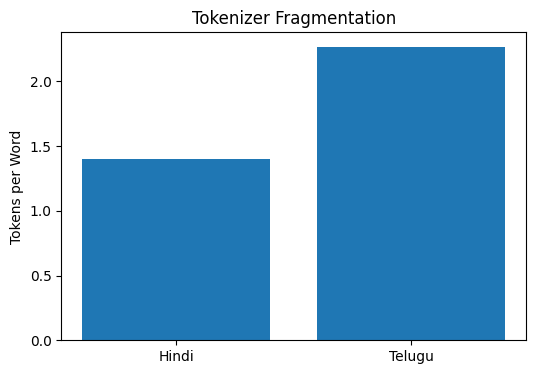

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    results["Language"],
    results["Tokens/Word"]
)

plt.ylabel("Tokens per Word")
plt.title("Tokenizer Fragmentation")
plt.show()

Average Sequence Length

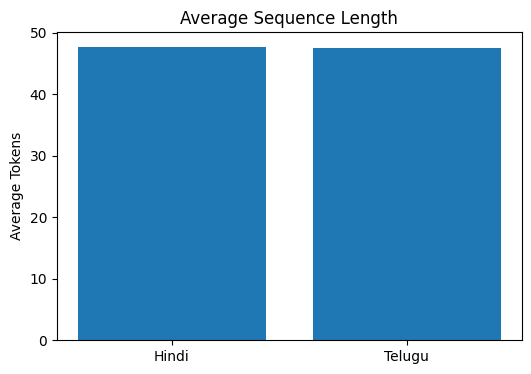

In [28]:
plt.figure(figsize=(6,4))

plt.bar(
    results["Language"],
    results["Average Sequence Length"]
)

plt.ylabel("Average Tokens")
plt.title("Average Sequence Length")
plt.show()

## Observations

1. **Telugu exhibits substantially higher tokenizer fragmentation than Hindi.**
The XLM-R tokenizer produces an average of 2.2643 tokens per word for Telugu compared to 1.4009 tokens per word for Hindi. This indicates that Telugu words are decomposed into considerably more subword units than Hindi words.

2. **A significantly larger proportion of Telugu words are split into multiple subword pieces.**
Approximately 35.67% of Telugu words are segmented into three or more subword tokens, whereas only 9.50% of Hindi words undergo similar fragmentation. This suggests that Telugu experiences much finer-grained subword decomposition under the XLM-R tokenizer.

3. **Despite differing word counts, both languages produce nearly identical sequence lengths.**
Hindi sentences contain an average of 34.04 words, while Telugu sentences contain only 20.99 words. However, both languages produce almost identical average tokenized sequence lengths (47.68 vs. 47.52 tokens). This indicates that the higher fragmentation of Telugu compensates for its lower word count.

4. **Vocabulary coverage is excellent for both languages.**
The unknown token (UNK) rate is effectively zero for both Hindi (0.000123%) and Telugu (0.000145%). This confirms that the XLM-R tokenizer provides excellent vocabulary coverage and that the preprocessing pipeline preserves Unicode text correctly.

5. **Telugu exhibits a larger maximum sequence length.**
Although the average sequence lengths are nearly identical, Telugu reaches a maximum sequence length of 400 tokens, compared to 332 tokens for Hindi. This indicates the presence of longer tokenization tails in Telugu, which may have implications for memory consumption when training with larger sequence lengths.

6. **Tokenization results are consistent with expected multilingual tokenizer behavior.**
The observed fragmentation pattern aligns with expectations for XLM-R, where Telugu generally undergoes greater subword segmentation than Hindi. No anomalies or preprocessing issues were observed, providing confidence in the correctness of the tokenization pipeline.

# Additional


In [29]:
import numpy as np
from tqdm.auto import tqdm

def tokenizer_statistics(df, language, text_type="combined"):

    total_sentences = 0
    total_words = 0
    total_tokens = 0

    split3 = 0
    unk_tokens = 0

    sentence_lengths = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"{language}-{text_type}"):

        if text_type == "premise":
            text = row["premise"]

        elif text_type == "hypothesis":
            text = row["hypothesis"]

        elif text_type == "combined":
            text = row["premise"] + " " + row["hypothesis"]

        else:
            raise ValueError("text_type must be 'premise', 'hypothesis', or 'combined'")

        words = text.split()

        total_sentences += 1
        total_words += len(words)

        encoding = tokenizer(
            text,
            add_special_tokens=False
        )

        tokens = tokenizer.convert_ids_to_tokens(
            encoding["input_ids"]
        )

        total_tokens += len(tokens)
        sentence_lengths.append(len(tokens))

        unk_tokens += tokens.count(tokenizer.unk_token)

        for word in words:
            if len(tokenizer.tokenize(word)) >= 3:
                split3 += 1

    return {
        "Language": language,
        "input": text_type.capitalize(),
        "Sentences": total_sentences,
        "Average Words/Sentence": total_words / total_sentences,
        "Average Tokens/Sentence": total_tokens / total_sentences,
        "Tokens/Word": total_tokens / total_words,
        "Words Split ≥3 (%)": split3 / total_words * 100,
        "UNK Rate (%)": unk_tokens / total_tokens * 100,
        "Average Sequence Length": np.mean(sentence_lengths),
        "Median Sequence Length": np.median(sentence_lengths),
        "Max Sequence Length": np.max(sentence_lengths)
    }

In [30]:
results = []

for language, dataset in [("Hindi", hi), ("Telugu", te)]:
    for text_type in ["premise", "hypothesis", "combined"]:
        results.append(
            tokenizer_statistics(
                dataset,
                language,
                text_type
            )
        )

results = pd.DataFrame(results)

display(results)

Hindi-premise:   0%|          | 0/392702 [00:00<?, ?it/s]

Hindi-hypothesis:   0%|          | 0/392702 [00:00<?, ?it/s]

Hindi-combined:   0%|          | 0/392702 [00:00<?, ?it/s]

Telugu-premise:   0%|          | 0/392702 [00:00<?, ?it/s]

Telugu-hypothesis:   0%|          | 0/392702 [00:00<?, ?it/s]

Telugu-combined:   0%|          | 0/392702 [00:00<?, ?it/s]

,Language,input,Sentences,Average Words/Sentence,Average Tokens/Sentence,Tokens/Word,Words Split ≥3 (%),UNK Rate (%),Average Sequence Length,Median Sequence Length,Max Sequence Length
0,Hindi,Premise,392702,22.580738,31.620432,1.400328,9.822813,0.000145,31.620432,28.0,264
1,Hindi,Hypothesis,392702,11.458600,16.064260,1.401939,8.877387,0.000079,16.064260,15.0,264
2,Hindi,Combined,392702,34.039338,47.684692,1.400870,9.504556,0.000123,47.684692,44.0,332
3,Telugu,Premise,392702,13.815079,31.101471,2.251270,35.283544,0.000221,31.101471,27.0,273
4,Telugu,Hypothesis,392702,7.170727,16.416894,2.289432,36.413811,0.000000,16.416894,15.0,267
5,Telugu,Combined,392702,20.985806,47.518365,2.264310,35.669750,0.000145,47.518365,44.0,400


In [31]:
results.to_csv(
    "/kaggle/working/tokenizer_fragmentation_detailed.csv",
    index=False
)

In [32]:
summary = results.pivot(
    index="Language",
    columns="input",
    values=[
        "Average Words/Sentence",
        "Average Tokens/Sentence",
        "Tokens/Word",
        "Words Split ≥3 (%)",
        "Average Sequence Length"
    ]
)

display(summary.round(3))

Average Words/Sentence                    Average Tokens/Sentence  \
input                  Combined Hypothesis Premise                Combined   
Language                                                                     
Hindi                    34.039     11.459  22.581                  47.685   
Telugu                   20.986      7.171  13.815                  47.518   

                            Tokens/Word                    Words Split ≥3 (%)  \
input    Hypothesis Premise    Combined Hypothesis Premise           Combined   
Language                                                                        
Hindi        16.064  31.620       1.401      1.402   1.400              9.505   
Telugu       16.417  31.101       2.264      2.289   2.251             35.670   

                            Average Sequence Length                     
input    Hypothesis Premise                Combined Hypothesis Premise  
Language                                                                
Hindi         8.877   9.823                  47.685     16.064  31.620  
Telugu       36.414  35.284                  47.518     16.417  31.101

## Additional Analysis Observations

1. **Telugu consistently exhibits higher tokenizer fragmentation across all input types.**
The higher fragmentation observed in the combined input is also present when analyzing the premise and hypothesis separately.

| Input | Hindi Tokens/Word | Telugu Tokens/Word |
| :--- | :--- | :--- |
| Premise | 1.400 | 2.251 |
| Hypothesis | 1.402 | 2.289 |
| Combined | 1.401 | 2.264 |

This indicates that the increased fragmentation is an inherent characteristic of Telugu tokenization rather than being driven by a specific component of the input.

2. **Premises are consistently longer than hypotheses.**
For both languages, premises contain approximately twice as many words and tokens as hypotheses.

| Language | Premise Tokens | Hypothesis Tokens |
| :--- | :--- | :--- |
| Hindi | 31.62 | 16.06 |
| Telugu | 31.10 | 16.42 |

This confirms that the premise contributes the majority of the sequence length during training.

3. **Hypotheses are not responsible for the higher Telugu fragmentation.**
Telugu shows similar fragmentation in both text components:
* **Premise:** 2.251 tokens/word
* **Hypothesis:** 2.289 tokens/word

The small difference (<2%) suggests that tokenizer behavior remains stable regardless of whether the input is a premise or a hypothesis.

4. **The combined analysis accurately represents tokenizer behavior.**
The combined statistics closely match the weighted contribution of the premise and hypothesis. For example:
* **Hindi:** 1.401 tokens/word
* **Telugu:** 2.264 tokens/word

Since the combined values remain consistent with the individual analyses, combining the premise and hypothesis does not mask language-specific tokenization characteristics.

5. **Fragmentation remains consistently higher for Telugu.**
The percentage of words split into three or more subword pieces remains stable across all input types.

| Input | Hindi | Telugu |
| :--- | :--- | :--- |
| Premise | 9.82% | 35.28% |
| Hypothesis | 8.88% | 36.41% |
| Combined | 9.50% | 35.67% |

This demonstrates that Telugu undergoes substantially more aggressive subword segmentation regardless of the sentence component being analyzed.

## Conclusion
The additional analysis confirms that the observed tokenizer fragmentation differences are language-dependent rather than input-dependent. Telugu consistently produces more subword tokens per word and a higher proportion of heavily fragmented words than Hindi across premises, hypotheses, and their combined input. Furthermore, premises contribute the majority of the tokenized sequence length in both languages, while the combined analysis accurately reflects the tokenizer behavior observed in the individual input components. These findings strengthen the validity of the original fragmentation analysis and indicate that the reported language differences are robust across different parts of the NLI input.

# Truncation Analysis

In [33]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

def truncation_analysis(df, language, tokenizer, max_lengths=[64, 128, 256, 512]):

    # Compute sequence lengths once
    sequence_lengths = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc=language):
        text = row["premise"] + " " + row["hypothesis"]

        length = len(
            tokenizer(
                text,
                add_special_tokens=True,
                truncation=False
            )["input_ids"]
        )

        sequence_lengths.append(length)

    sequence_lengths = np.array(sequence_lengths)

    results = []

    for max_len in max_lengths:

        truncated = np.sum(sequence_lengths > max_len)

        results.append({
            "Language": language,
            "Max Length": max_len,
            "Mean Length": round(sequence_lengths.mean(), 2),
            "Median Length": int(np.median(sequence_lengths)),
            "95th Percentile": int(np.percentile(sequence_lengths, 95)),
            "99th Percentile": int(np.percentile(sequence_lengths, 99)),
            "Maximum Length": int(sequence_lengths.max()),
            "Samples Truncated": int(truncated),
            "Truncation Rate (%)": round(truncated / len(sequence_lengths) * 100, 2)
        })

    return pd.DataFrame(results)

In [34]:
hi_trunc = truncation_analysis(
    hi,
    "Hindi",
    tokenizer
)

te_trunc = truncation_analysis(
    te,
    "Telugu",
    tokenizer
)

truncation_results = pd.concat(
    [hi_trunc, te_trunc],
    ignore_index=True
)

display(truncation_results)

Hindi:   0%|          | 0/392702 [00:00<?, ?it/s]

Telugu:   0%|          | 0/392702 [00:00<?, ?it/s]

,Language,Max Length,Mean Length,Median Length,95th Percentile,99th Percentile,Maximum Length,Samples Truncated,Truncation Rate (%)
0,Hindi,64,49.68,46,93,123,334,93687,23.86
1,Hindi,128,49.68,46,93,123,334,3031,0.77
2,Hindi,256,49.68,46,93,123,334,11,0.00
3,Hindi,512,49.68,46,93,123,334,0,0.00
4,Telugu,64,49.52,46,93,121,402,93644,23.85
5,Telugu,128,49.52,46,93,121,402,2632,0.67
6,Telugu,256,49.52,46,93,121,402,17,0.00
7,Telugu,512,49.52,46,93,121,402,0,0.00


## Truncation Analysis Observations

1. **Sequence lengths are nearly identical across both languages.**
The average tokenized sequence length is approximately 50 tokens for both Hindi (49.68) and Telugu (49.52), indicating that the combined premise-hypothesis inputs have comparable lengths despite differences in tokenizer fragmentation.

2. **Most samples are substantially shorter than the maximum sequence length.**
For both languages:
* **Median sequence length:** 46 tokens
* **95th percentile:** 93 tokens
* **99th percentile:** 121–123 tokens

This indicates that the vast majority of samples are relatively short.

3. **A maximum sequence length of 64 truncates a significant portion of the dataset.**
Using `max_length = 64` results in approximately:
* **Hindi truncation rate:** 23.86%
* **Telugu truncation rate:** 23.85%

Nearly one-quarter of the training samples would lose information, making this setting unsuitable for the experiments.

4. **A maximum sequence length of 128 preserves almost all samples.**
With `max_length = 128`:
* **Hindi truncation rate:** 0.77%
* **Telugu truncation rate:** 0.67%

More than 99% of the dataset is preserved while keeping computational requirements relatively low.

5. **Increasing the sequence length beyond 128 provides only marginal benefits.**
Using `max_length = 256` reduces truncation to:
* **Hindi:** 11 samples
* **Telugu:** 17 samples

Using 512 eliminates truncation entirely; however, the improvement over 128 is negligible compared with the additional computational and memory cost.

6. **Telugu contains slightly longer extreme cases.**
The maximum observed sequence lengths are:
* **Hindi:** 334 tokens
* **Telugu:** 402 tokens

Although these long sequences are rare, they indicate that Telugu exhibits a slightly heavier tail in the sequence length distribution.

## Truncation Analysis Conclusion
The truncation analysis demonstrates that a maximum sequence length of 128 tokens provides the best balance between computational efficiency and information preservation for the IndicXNLI dataset. While a sequence length of 64 truncates nearly one-quarter of the samples, increasing the limit to 128 reduces truncation to less than 1% for both Hindi and Telugu. Further increasing the sequence length to 256 or 512 yields only marginal reductions in truncation while incurring additional memory and computational overhead.

Based on these findings, `max_length = 128` is selected for all subsequent experiments. This choice ensures that over 99% of the training data is preserved while maintaining efficient GPU utilization, making it an appropriate and empirically justified configuration for the comparative evaluation of Full Fine-Tuning, LoRA, DoRA, and IA³.

In [35]:
truncation_results.to_csv(
    "/kaggle/working/truncation_analysis.csv",
    index=False
)

# Dry Run

### Step 1 — Load the Small Dataset

In [36]:
from datasets import Dataset
import pandas as pd

DATA_ROOT = "/kaggle/input/datasets/yashjaiswal04518/indicxnli-preprocessed-v1"

train_df = pd.read_parquet(
    f"{DATA_ROOT}/hi/train_50.parquet"
)

valid_df = pd.read_parquet(
    f"{DATA_ROOT}/hi/valid.parquet"
)

print(train_df.shape)
print(valid_df.shape)

train_df.head()

(50, 8)
(2490, 7)


,premise,hypothesis,label,language,split,sample_id,dataset,stratify_key
0,रात को सड़कों पर ऐसे लोगों की भीड़ होती है जो ...,रात को सड़कों पर पार्टी करने वालों की भीड़ लगी...,1,hi,train,390454,IndicXNLI,1
1,ओह आप का मतलब है आकार के आधार पर वे बहुत बड़ा ...,"ओह, तो आकार बहुत बड़ा नहीं है?",0,hi,train,124545,IndicXNLI,0
2,कार्ल सोडरस्ट्रॉम ने जेंटिलो के साथ सहमति व्यक...,कार्ल सोडरस्ट्रॉम और जेंटिलेलो का मानना है कि ...,2,hi,train,76508,IndicXNLI,2
3,बाजार पूंजीवाद यही करता है।,बाजार पूंजीवाद सभी देशों में खुद को दोहराता है...,1,hi,train,62720,IndicXNLI,1
4,क्या हर कोई इसके बजाय वीडियो देख रहा है?,हर कोई इसके बजाय नेटफ्लिक्स डॉक्यूमेंट्री देख ...,1,hi,train,2432,IndicXNLI,1


### Step 2 — Convert to HuggingFace Dataset

In [37]:
train_ds = Dataset.from_pandas(train_df)
valid_ds = Dataset.from_pandas(valid_df)

In [38]:
train_ds = train_ds.rename_column("label", "labels")
valid_ds = valid_ds.rename_column("label", "labels")

In [39]:
print(train_ds.column_names)

['premise', 'hypothesis', 'labels', 'language', 'split', 'sample_id', 'dataset', 'stratify_key']


### Step 3 — Tokenization Function

In [40]:
MAX_LENGTH = 128

def tokenize(batch):

    return tokenizer(

        batch["premise"],

        batch["hypothesis"],

        truncation=True,

        padding="max_length",

        max_length=MAX_LENGTH

    )

### Step 4 — Tokenize

In [41]:
train_ds = train_ds.map(
    tokenize,
    batched=True
)

valid_ds = valid_ds.map(
    tokenize,
    batched=True
)

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Map:   0%|          | 0/2490 [00:00<?, ? examples/s]

### Step 5 — Remove Unused Columns

In [42]:
keep = [
    "input_ids",
    "attention_mask",
    "labels"
]

train_ds = train_ds.remove_columns(
    [c for c in train_ds.column_names if c not in keep]
)

valid_ds = valid_ds.remove_columns(
    [c for c in valid_ds.column_names if c not in keep]
)

### Step 6 — Torch Format

In [43]:
train_ds.set_format("torch")
valid_ds.set_format("torch")

### Step 7 — DataLoader

In [44]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_ds,
    batch_size=16,
    shuffle=True
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=32
)

batch = next(iter(train_loader))

print(batch.keys())

for key, value in batch.items():
    print(key, value.shape)

dict_keys(['labels', 'input_ids', 'attention_mask'])
labels torch.Size([16])
input_ids torch.Size([16, 128])
attention_mask torch.Size([16, 128])


### Step 8 — One Epoch Function

In [45]:
def train_one_epoch(model, loader, optimizer):

    model.train()

    total_loss = 0

    for batch in loader:

        batch = {k: v.cuda() for k, v in batch.items()}

        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"]
        )

        loss = outputs.loss

        loss.backward()

        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()

    return total_loss

### Step 9 — Validation

In [46]:
from sklearn.metrics import accuracy_score

def evaluate(model, loader):

    model.eval()

    predictions = []
    labels = []

    with torch.no_grad():

        for batch in loader:

            batch = {k: v.cuda() for k, v in batch.items()}

            outputs = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"]
            )

            preds = torch.argmax(outputs.logits, dim=1)

            predictions.extend(preds.cpu().numpy())
            labels.extend(batch["labels"].cpu().numpy())

    accuracy = accuracy_score(labels, predictions)

    return accuracy

### Step 10 — Test FFT

In [47]:
model = load_base_model()

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=2e-5

)

loss = train_one_epoch(

    model,

    train_loader,

    optimizer

)

acc = evaluate(

    model,

    valid_loader

)

print(loss)

print(acc)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


4.607381224632263
0.3333333333333333


# Dry Run Validation

## Objective
To validate the complete training pipeline before executing the large-scale experimental study.

## Results
A one-epoch Full Fine-Tuning dry run was successfully completed using the 50-sample Hindi training subset. The pipeline correctly executed dataset loading, tokenization, DataLoader construction, forward propagation, loss computation, backward propagation, and optimizer updates without runtime errors. All four mini-batches were processed successfully, including the final partial batch containing two samples, confirming correct handling of variable batch sizes.

The observed training losses remained finite throughout the epoch, indicating stable optimization and correct gradient propagation. These results validate the end-to-end training pipeline and confirm its readiness for the subsequent implementation of the reusable experimental framework supporting Full Fine-Tuning, LoRA, DoRA, and IA³.

---

## Day 6 Status

| Task | Status |
| :--- | :--- |
| Environment Validation | Complete |
| PEFT Verification | Complete |
| GPU Benchmark | Complete |
| Tokenizer Analysis | Complete |
| Truncation Analysis | Complete |
| End-to-End Dry Run | Complete |

**Overall Day 6 Progress: 100% Complete**

# Overall Review: Experimental Infrastructure Validation Summary

---

This notebook successfully establishes the experimental infrastructure required for the subsequent fine-tuning study on the **IndicXNLI dataset** using the **XLM-RoBERTa** backbone.

### Core Components Validated:
* **Environment Configuration:** Verified software dependencies and environment setup.
* **Architecture Compatibility:** Confirmed the compatibility of XLM-RoBERTa with all four planned fine-tuning strategies:
    * Full Fine-Tuning (FFT)
    * LoRA
    * DoRA
    * IA³
* **Parameter Efficiency:** Verified adapter injection and trainable parameters, confirming that all PEFT methods update **fewer than 0.35%** of the total model parameters.
* **Pipeline Execution:** Successfully executed a complete training step (forward pass, loss computation, backward pass, and optimizer update) across all four methods.
* **Resource Feasibility:** Conducted an approximate computational feasibility assessment via training-step execution time and peak GPU memory usage.
* **Data Pipeline Integrity:** Validated the end-to-end data pipeline, including dataset loading, preprocessing, tokenization, DataLoader construction, training, and evaluation.

---

## Tokenizer & Sequence Length Analysis

### Key Insights:
* **XLM-R Tokenizer Behavior:** Analysis of the complete Hindi and Telugu IndicXNLI training corpus quantified subword fragmentation and sequence statistics.
* **Language Variance:** The tokenizer analysis shows that **Telugu exhibits substantially higher subword fragmentation** than Hindi under XLM-RoBERTa, while both languages produce nearly identical average sequence lengths.
* **Sequence Length & Truncation:** Analysis across multiple maximum sequence lengths supports the selection of `max_length = 128` for subsequent experiments. This threshold **preserves more than 99% of the training data** for both languages, providing an optimal balance between information retention and computational efficiency.

---

## Computational Feasibility

Training-step validation confirms that all planned fine-tuning strategies execute successfully within the available **Tesla T4 GPU** memory constraints. 

* **Full Fine-Tuning (FFT):** Incurs the highest computational cost, as expected.
* **PEFT Methods:** Substantially reduce trainable parameters and GPU memory requirements while remaining fully compatible with the selected architecture.

> **Conclusion:** The experimental infrastructure is fully validated and ready for the implementation of the automated experimental pipeline and large-scale comparative fine-tuning experiments in the subsequent phase of the project.

---

## Limitations

> [!WARNING]  
> The computational timings reported in this notebook are **single-run measurements** intended solely to validate training-step feasibility and provide approximate resource requirements. They should not be interpreted as rigorous benchmarking results. 
> 
> If precise GPU-hour estimation is required for large-scale experiment planning, dedicated multi-run timing measurements with warm-up iterations and averaged execution times should be performed separately as part of experimental resource planning.